1 - Criar um classificador de floresta aleatória para o conjunto de dados de vinhos a
seguir:
(https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#s
klearn.datasets.load_wine)
Mostrar a variação da acurácia quando se varia o número de árvores entre 5 e 50.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Carregar os dados
wine = load_wine(return_X_y=True)
X, y = wine

In [3]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [4]:
# Lista para armazenar resultados
n_trees = list(range(5, 51, 5))
accuracies = []

In [5]:
# Loop variando número de árvores
for n in n_trees:
    clf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"n_estimators = {n:2d} → Acurácia = {acc:.4f}")

n_estimators =  5 → Acurácia = 0.9630
n_estimators = 10 → Acurácia = 0.9630
n_estimators = 15 → Acurácia = 0.9815
n_estimators = 20 → Acurácia = 0.9815
n_estimators = 25 → Acurácia = 1.0000
n_estimators = 30 → Acurácia = 1.0000
n_estimators = 35 → Acurácia = 1.0000
n_estimators = 40 → Acurácia = 1.0000
n_estimators = 45 → Acurácia = 1.0000
n_estimators = 50 → Acurácia = 1.0000


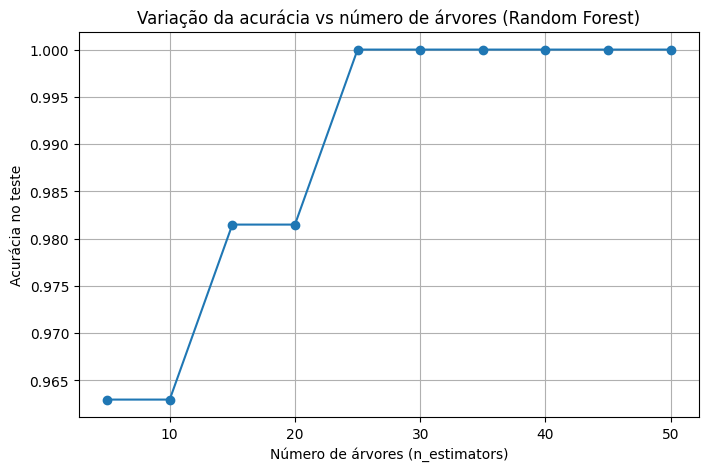

In [6]:
# Plotar o resultado
plt.figure(figsize=(8,5))
plt.plot(n_trees, accuracies, marker='o')
plt.title("Variação da acurácia vs número de árvores (Random Forest)")
plt.xlabel("Número de árvores (n_estimators)")
plt.ylabel("Acurácia no teste")
plt.grid(True)
plt.show()

2 - Criar um regressor de floresta aleatória para o conjunto de dados Abalone.
Mostrar a variação da acurácia quando se varia o número de árvores entre 5 e 50.
Explique o código e comente as respostas

In [8]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
cols = ["sex", "length", "diameter", "height", "whole_weight",
        "shucked_weight", "viscera_weight", "shell_weight", "rings"]

In [10]:
df = pd.read_csv(url, header=None, names=cols)
df = pd.get_dummies(df, columns=["sex"], drop_first=True)

In [12]:
X = df.drop("rings", axis=1).values
y = df["rings"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
n_trees = list(range(5, 51, 5))
r2_scores = []

for n in n_trees:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f"n_estimators = {n:2d} → R² = {r2:.4f}")

n_estimators =  5 → R² = 0.4302
n_estimators = 10 → R² = 0.4932
n_estimators = 15 → R² = 0.5044
n_estimators = 20 → R² = 0.5051
n_estimators = 25 → R² = 0.5095
n_estimators = 30 → R² = 0.5183
n_estimators = 35 → R² = 0.5194
n_estimators = 40 → R² = 0.5221
n_estimators = 45 → R² = 0.5269
n_estimators = 50 → R² = 0.5258


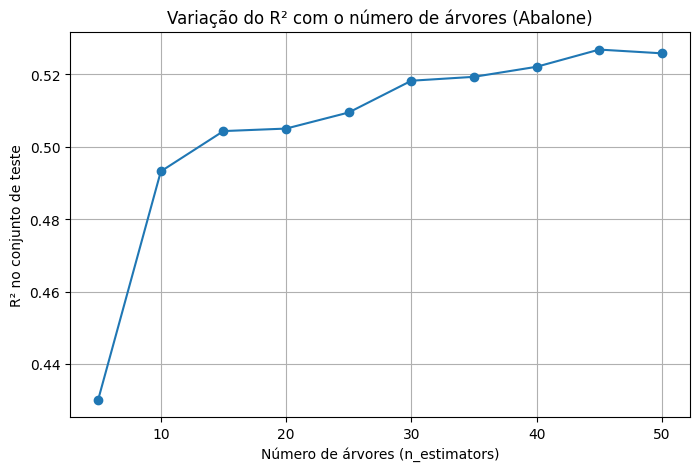

In [14]:
# Plotar a variação do R²
plt.figure(figsize=(8,5))
plt.plot(n_trees, r2_scores, marker='o')
plt.title("Variação do R² com o número de árvores (Abalone)")
plt.xlabel("Número de árvores (n_estimators)")
plt.ylabel("R² no conjunto de teste")
plt.grid(True)
plt.show()